# 1.2 Datos Transversales

Multiples entidades medidas en un único instante de tiempo

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

data = pd.read_csv('C:/Users/FBA/OneDrive - Acesco/0. Personales/2. Profesional/20240416 - Maestria en Analítica de Datos/20240919 Series de Tiempo/Semana 1/datasets/WDIData.csv')
print('Column names:', data.columns)

Column names: Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', 'Unnamed: 61'],
      dtype='object')


In [2]:
print('No. of rows, columns:', data.shape)

No. of rows, columns: (401016, 62)


In [3]:
nb_countries = data['Country Code'].unique().shape[0]
print('Unique number of countries:', nb_countries)

Unique number of countries: 264


In [4]:
data.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2013              float64
2014              float64
2015              float64
2016              float64
Unnamed: 61       float64
Length: 62, dtype: object

In [5]:
central_govt_debt = data.loc[data['Indicator Name']=='Central government debt, total (% of GDP)']
military_exp = data.loc[data['Indicator Name']=='Military expenditure (% of GDP)']

print('Shape of central_govt_debt:', central_govt_debt.shape)
print('Shape of military_exp:', military_exp.shape)

Shape of central_govt_debt: (264, 62)
Shape of military_exp: (264, 62)


In [6]:
central_govt_debt['2010'].describe()

count     94.000000
mean      53.048479
std       29.790674
min        0.519665
25%       28.357797
50%       49.540245
75%       75.259012
max      161.596402
Name: 2010, dtype: float64

In [7]:
military_exp['2010'].describe()

count    192.000000
mean       1.988556
std        1.354856
min        0.000000
25%        1.190287
50%        1.613407
75%        2.624711
max        8.565679
Name: 2010, dtype: float64

In [8]:
#Definir Country Code, como indicador:
central_govt_debt.index = central_govt_debt['Country Code']
military_exp.index = military_exp['Country Code']

In [9]:
central_govt_debt_2010 = central_govt_debt['2010'].loc[~pd.isnull(central_govt_debt['2010'])]
military_exp_2010 = military_exp['2010'].loc[~pd.isnull(military_exp['2010'])]

central_govt_debt_2010

Country Code
CEB    47.446156
EMU    72.414709
ECS    63.137736
ECA    22.338687
TEC    27.287492
         ...    
UGA    27.552595
UKR    29.969556
GBR    83.406797
USA    85.601594
URY    44.222702
Name: 2010, Length: 94, dtype: float64

In [10]:
military_exp_2010

Country Code
ARB    5.117807
CEB    1.482543
EAR    2.335511
EAS    1.563325
EAP    1.724963
         ...   
VEN    0.853924
VNM    2.305049
YEM    4.685557
ZMB    1.382593
ZWE    0.977841
Name: 2010, Length: 192, dtype: float64

In [11]:
data_to_plot = pd.concat((central_govt_debt_2010, military_exp_2010), axis=1)
data_to_plot.columns = ['central_govt_debt', 'military_exp']

data_to_plot.head()

,central_govt_debt,military_exp
Country Code,,
CEB,47.446156,1.482543
EMU,72.414709,1.618759
ECS,63.137736,1.860343
ECA,22.338687,2.933044
TEC,27.287492,2.785617


In [12]:
data_to_plot.shape

(202, 2)

In [13]:
data_to_plot = data_to_plot.loc[(~pd.isnull(data_to_plot.central_govt_debt)) & (~pd.isnull(data_to_plot.military_exp)), :]
data_to_plot.head()


,central_govt_debt,military_exp
Country Code,,
CEB,47.446156,1.482543
EMU,72.414709,1.618759
ECS,63.137736,1.860343
ECA,22.338687,2.933044
TEC,27.287492,2.785617


In [14]:
data_to_plot.shape

(84, 2)

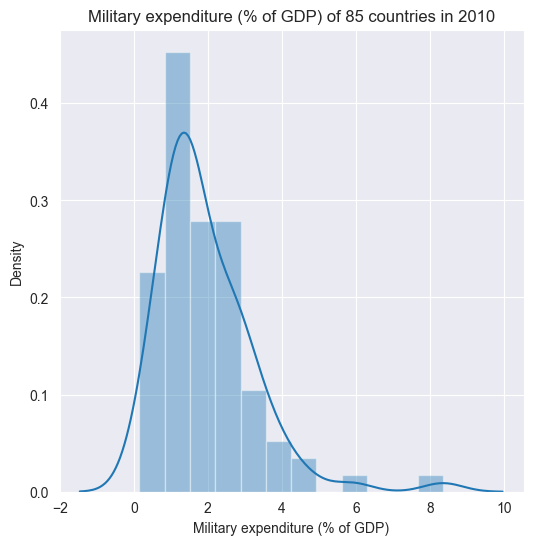

In [15]:
military_exp_np = np.array(data_to_plot.military_exp)
plt.figure(figsize=(6, 6))
g = sns.distplot(military_exp_np, norm_hist=False)
g.set_title('Military expenditure (% of GDP) of 85 countries in 2010');
plt.xlabel("Military expenditure (% of GDP)");

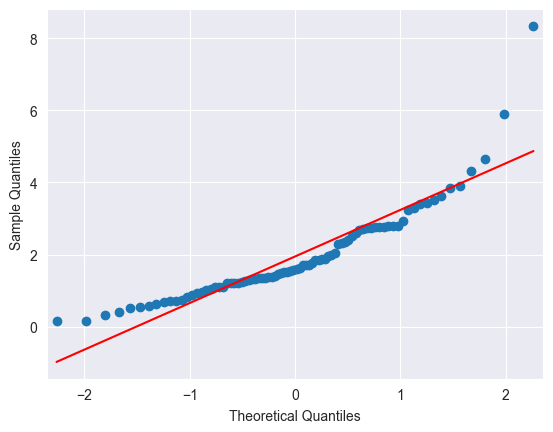

In [16]:
from statsmodels.graphics.gofplots import qqplot
qqplot(military_exp_np, line='s');

In [17]:
from scipy.stats import shapiro

print('Shapiro-Wilk Test:')
stat, p = shapiro(military_exp_np)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Shapiro-Wilk Test:
Statistics=0.857023, p=1.646573e-07
Sample does not look Normal (reject H0)


In [18]:
import numpy as np
from scipy import stats

print('Kolmogorov-Smirnov:')
stat, p = stats.kstest(military_exp_np, stats.norm.cdf)
print('Statistics=%.6f, p=%e' % (stat, p))

alpha = 0.05
if p > alpha:
 print('Sample looks Normal (fail to reject H0)')
else:
 print('Sample does not look Normal (reject H0)')

Kolmogorov-Smirnov:
Statistics=0.659326, p=2.320049e-36
Sample does not look Normal (reject H0)


# Series temporales



Una entidad medida en multiples instantes de tiempo

In [19]:
central_govt_debt_us = central_govt_debt.loc[central_govt_debt['Country Code']=='USA', :].T
military_exp_us = military_exp.loc[military_exp['Country Code']=='USA', :].T

data_us = pd.concat((military_exp_us, central_govt_debt_us), axis=1)
index0 = np.where(data_us.index=='1960')[0][0]
index1 = np.where(data_us.index=='2010')[0][0]
data_us = data_us.iloc[index0:index1+1,:]
data_us.columns = ['Federal Military Expenditure', 'Debt of Federal Government']
data_us.head()

,Federal Military Expenditure,Debt of Federal Government
1960,8.35266,NaN
1961,8.487129,NaN
1962,8.656586,NaN
1963,8.189007,NaN
1964,7.467629,NaN


In [20]:
data_us['backward_fill'] = data_us['Debt of Federal Government'].bfill()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill
1960,8.35266,NaN,39.016963
1961,8.487129,NaN,39.016963
1962,8.656586,NaN,39.016963
1963,8.189007,NaN,39.016963
1964,7.467629,NaN,39.016963


In [21]:
data_us['mean_fill'] = data_us['Debt of Federal Government'].mean()
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill
1960,8.35266,NaN,39.016963,51.155537
1961,8.487129,NaN,39.016963,51.155537
1962,8.656586,NaN,39.016963,51.155537
1963,8.189007,NaN,39.016963,51.155537
1964,7.467629,NaN,39.016963,51.155537


In [22]:
data_us['quadratic_fill'] = data_us['Debt of Federal Government'].interpolate(option='quadratic')
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,quadratic_fill
1960,8.35266,NaN,39.016963,51.155537,NaN
1961,8.487129,NaN,39.016963,51.155537,NaN
1962,8.656586,NaN,39.016963,51.155537,NaN
1963,8.189007,NaN,39.016963,51.155537,NaN
1964,7.467629,NaN,39.016963,51.155537,NaN


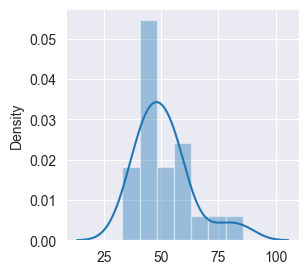

In [23]:
quadratic = np.array(data_us.quadratic_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(quadratic, norm_hist=False)

In [24]:
data_us['nearest_fill'] = data_us['Debt of Federal Government'].interpolate(option='nearest')
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,quadratic_fill,nearest_fill
1960,8.35266,NaN,39.016963,51.155537,NaN,NaN
1961,8.487129,NaN,39.016963,51.155537,NaN,NaN
1962,8.656586,NaN,39.016963,51.155537,NaN,NaN
1963,8.189007,NaN,39.016963,51.155537,NaN,NaN
1964,7.467629,NaN,39.016963,51.155537,NaN,NaN


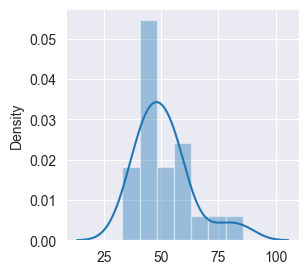

In [25]:
nearest = np.array(data_us.nearest_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(nearest, norm_hist=False)

In [26]:
data_us['zero_fill'] = data_us['Debt of Federal Government'].interpolate(option='zero',limit_direction='both')
data_us.head()

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,quadratic_fill,nearest_fill,zero_fill
1960,8.35266,NaN,39.016963,51.155537,NaN,NaN,NaN
1961,8.487129,NaN,39.016963,51.155537,NaN,NaN,NaN
1962,8.656586,NaN,39.016963,51.155537,NaN,NaN,NaN
1963,8.189007,NaN,39.016963,51.155537,NaN,NaN,NaN
1964,7.467629,NaN,39.016963,51.155537,NaN,NaN,NaN


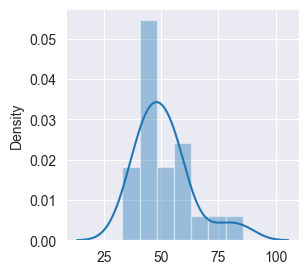

In [27]:
zero = np.array(data_us.zero_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(zero, norm_hist=False)

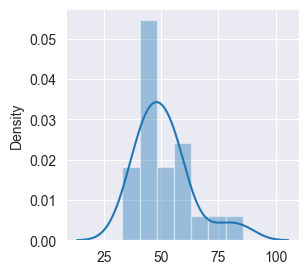

In [28]:
data_us['slinear_fill'] = data_us['Debt of Federal Government'].interpolate(option='slinear',limit_direction='both')
data_us.head()
slinear = np.array(data_us.slinear_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(slinear, norm_hist=False)

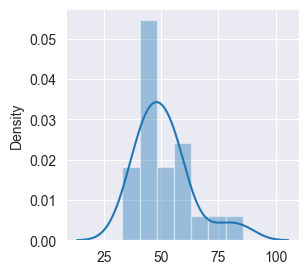

In [29]:
data_us['cubic_fill'] = data_us['Debt of Federal Government'].interpolate(option='cubic',limit_direction='both')
data_us.head()
cubic = np.array(data_us.cubic_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(cubic, norm_hist=False)

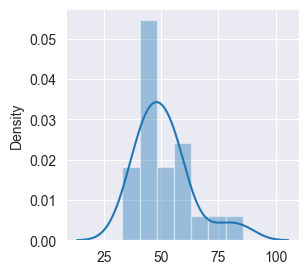

In [30]:
data_us['spline_fill'] = data_us['Debt of Federal Government'].interpolate(option='spline',limit_direction='both')
data_us.head()
spline = np.array(data_us.spline_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(spline, norm_hist=False)

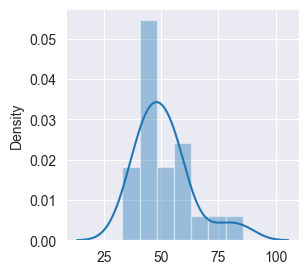

In [31]:
data_us['barycentric_fill'] = data_us['Debt of Federal Government'].interpolate(option='barycentric',limit_direction='both')
data_us.head()
barycentric = np.array(data_us.barycentric_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(barycentric, norm_hist=False)

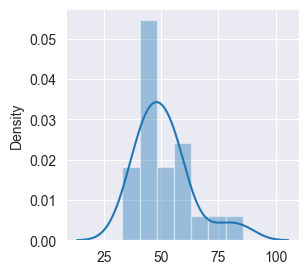

In [32]:
data_us['polynomial_fill'] = data_us['Debt of Federal Government'].interpolate(option='polynomial',limit_direction='both')
polynomial = np.array(data_us.polynomial_fill)
plt.figure(figsize=(3, 3))
g = sns.distplot(polynomial, norm_hist=False)

In [33]:
data_us.head(5)

,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,quadratic_fill,nearest_fill,zero_fill,slinear_fill,cubic_fill,spline_fill,barycentric_fill,polynomial_fill
1960,8.35266,NaN,39.016963,51.155537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,8.487129,NaN,39.016963,51.155537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,8.656586,NaN,39.016963,51.155537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,8.189007,NaN,39.016963,51.155537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964,7.467629,NaN,39.016963,51.155537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
data_us.dropna(inplace=True)
print('Shape of data_us:', data_us.shape)
data_us.head(5)

Shape of data_us: (22, 12)


,Federal Military Expenditure,Debt of Federal Government,backward_fill,mean_fill,quadratic_fill,nearest_fill,zero_fill,slinear_fill,cubic_fill,spline_fill,barycentric_fill,polynomial_fill
1989,5.374717,39.016963,39.016963,51.155537,39.016963,39.016963,39.016963,39.016963,39.016963,39.016963,39.016963,39.016963
1990,5.120252,40.821367,40.821367,51.155537,40.821367,40.821367,40.821367,40.821367,40.821367,40.821367,40.821367,40.821367
1991,4.539845,43.948026,43.948026,51.155537,43.948026,43.948026,43.948026,43.948026,43.948026,43.948026,43.948026,43.948026
1992,4.666265,45.916542,45.916542,51.155537,45.916542,45.916542,45.916542,45.916542,45.916542,45.916542,45.916542,45.916542
1993,4.326925,48.104749,48.104749,51.155537,48.104749,48.104749,48.104749,48.104749,48.104749,48.104749,48.104749,48.104749


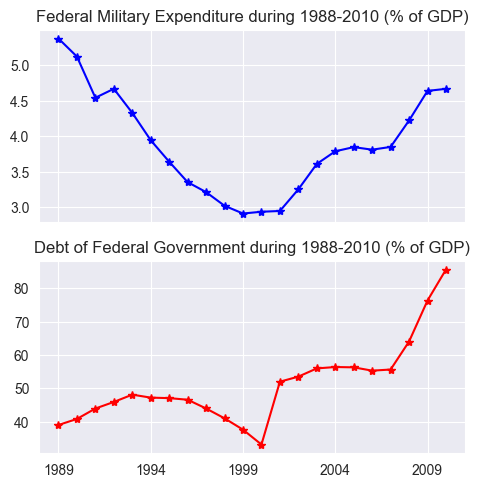

In [35]:
f, axarr = plt.subplots(2, sharex=True)
f.set_size_inches(5.5, 5.5)
axarr[0].set_title('Federal Military Expenditure during 1988-2010 (% of GDP)')
data_us['Federal Military Expenditure'].plot(linestyle='-', marker='*', color='b', ax=axarr[0])
axarr[1].set_title('Debt of Federal Government during 1988-2010 (% of GDP)')
data_us['Debt of Federal Government'].plot(linestyle='-', marker='*', color='r', ax=axarr[1]);

# Datos de Panel

Multiples entidades siendo medidas en multiples instantes en el tiempo. (midiendo la misma caracteristica)

In [36]:
chn = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='CHN'), :] #China

chn = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='CHN'), :].drop(data.columns[range(3)], axis=1)

chn = pd.Series(data=chn.values[0], index=chn.columns)
chn.dropna(inplace=True)
chn.head()


Indicator Code    MS.MIL.XPND.GD.ZS
1989                       2.499185
1990                       2.555996
1991                       2.407892
1992                       2.518629
dtype: object

In [37]:
usa = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='USA'), :].drop(data.columns[range(3)], axis=1) #USA
usa = pd.Series(data=usa.values[0], index=usa.columns)
usa.dropna(inplace=True)
usa.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1960                        8.35266
1961                       8.487129
1962                       8.656586
1963                       8.189007
dtype: object

In [38]:
ind = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='IND'), :].drop(data.columns[range(3)], axis=1) #India
ind = pd.Series(data=ind.values[0], index=ind.columns)
ind.dropna(inplace=True)
ind.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1960                       1.866015
1961                       1.933365
1962                       2.561202
1963                       3.758057
dtype: object

In [39]:
gbr = data.loc[(data['Indicator Name']=='Military expenditure (% of GDP)') & \
               (data['Country Code']=='GBR'), :].drop(data.columns[range(3)], axis=1) #United Kingdom
gbr = pd.Series(data=gbr.values[0], index=gbr.columns)
gbr.dropna(inplace=True)
gbr.head()

Indicator Code    MS.MIL.XPND.GD.ZS
1960                       6.343041
1961                       6.190022
1962                       6.210394
1963                       6.082126
dtype: object

#Years:  30


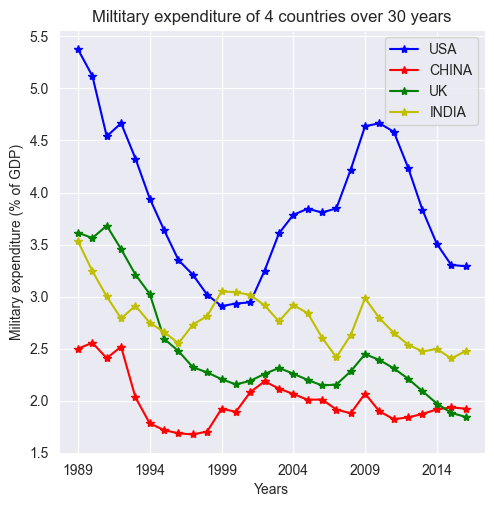

In [40]:
n_years = chn.shape[0]
print("#Years: ", n_years+1)
plt.figure(figsize=(5.5, 5.5))
usa[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='b')
chn[1:n_years].plot(linestyle='-', marker='*', color='r')
gbr[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='g')
ind[n_years+1:2*n_years].plot(linestyle='-', marker='*', color='y')
plt.legend(['USA','CHINA','UK','INDIA'], loc=1)
plt.title('Miltitary expenditure of 4 countries over 30 years')
plt.ylabel('Military expenditure (% of GDP)')
plt.xlabel('Years');